# Robust Sensor Placement under Non-Stationary Target Intensity
## A Toy Simulation Study — Extension of Kim et al. (2024)

**Author:** Lipheng  
**Date:** May 2026  

This notebook implements and evaluates my proposed extension to the barrier coverage 
sensor placement framework from:

> M. Kim, D. J. Stilwell, H. Yetkin, and J. Jimenez, "Near-optimal Sensor Placement 
> for Detecting Stochastic Target Trajectories in Barrier Coverage Systems," IEEE, 2024.

**My key idea:** The original paper optimizes sensor locations for a single, fixed target 
intensity function. I extend this to handle *non-stationary* intensity where traffic 
patterns change across time periods using a worst-case robust (maximin) formulation.

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
import warnings
warnings.filterwarnings('ignore')

# For reproducibility
np.random.seed(42)
print("All libraries loaded successfully.")

All libraries loaded successfully.


## 1. Setting Up the Representation Space

Following Kim et al. [1], I parameterize every straight-line trajectory by two values:
- **α** (alpha): the angle of the line's normal vector  
- **p**: the signed perpendicular distance from the origin

This maps each line in the physical "inertial space" $\mathcal{A}$ to a unique point 
$(\alpha, p)$ in the "representation space" $\mathcal{C}$ (see [2] for the geometric foundations).

I discretize this space on a 40×40 grid for numerical integration.

In [26]:
# Domain setup
L = 10.0  # half-width of inertial space (km), so A = [-10, 10]^2

# Representation space discretization
N_alpha = 40
N_p = 40
alpha_grid = np.linspace(5 * np.pi / 180, 175 * np.pi / 180, N_alpha)
p_max = L * np.sqrt(2)
p_grid = np.linspace(-p_max, p_max, N_p)
ALPHA, P_GRID = np.meshgrid(alpha_grid, p_grid, indexing='ij')  # shape (N_alpha, N_p)

# Integration cell area
d_alpha = alpha_grid[1] - alpha_grid[0]
d_p = p_grid[1] - p_grid[0]
cell_area = d_alpha * d_p

print(f"Inertial domain: [{-L}, {L}] x [{-L}, {L}] km")
print(f"Representation space: alpha in [{np.degrees(alpha_grid[0]):.1f}, {np.degrees(alpha_grid[-1]):.1f}] deg, p in [{p_grid[0]:.2f}, {p_grid[-1]:.2f}] km")
print(f"Grid: {N_alpha} x {N_p} = {N_alpha * N_p} cells, cell area = {cell_area:.6f}")

Inertial domain: [-10.0, 10.0] x [-10.0, 10.0] km
Representation space: alpha in [5.0, 175.0] deg, p in [-14.14, 14.14] km
Grid: 40 x 40 = 1600 cells, cell area = 0.055175


## 2. Defining Non-Stationary Intensity Scenarios

In the original paper, a single log-Gaussian Cox process (LGCP) intensity $\lambda(l)$ is estimated 
from historical AIS ship data using INLA [3, 4]. **I argue that this is a limitation** that real maritime 
traffic varies across months, seasons, weather conditions and between day/night. For instance, a deployment optimized for January may 
have blind spots in July.

To model this, I define **K = 3 synthetic intensity scenarios**, each representing a distinct traffic 
pattern. In practice, these would come from running INLA separately on different time windows of AIS data.
- **Scenario 1**: Channel is concentrated corridor near alpha=90deg, p=0-3 km (e.g., main shipping lane in calm season)
- **Scenario 2**: Spread is a two crossing corridors at ~45deg and ~135deg (e.g., divergent routes during storm season)
- **Scenario 3**: Shifted is a three diffuse clusters at varied angles (e.g., re-routed traffic during construction/event)

I use Gaussian mixtures with total intensity in the representation space as a simple and practical way to approximate the distribution:

$$\lambda_k(\alpha, p) = \lambda_0 + \sum_j w_j \exp\left(-\frac{1}{2}\left[\frac{(\alpha - \mu_{\alpha,j})^2}{\sigma_{\alpha,j}^2} + \frac{(p - \mu_{p,j})^2}{\sigma_{p,j}^2}\right]\right)$$

**Assumption A1:** I calibrate the peak amplitudes so total integrated intensity is ~3.0–3.6, 
which produces void probabilities in the 0.05–0.45 range (consistent with Table I of [1]).

In [27]:
def make_intensity(centers, spreads, weights, baseline=0.012):
    """Build intensity as mixture of Gaussians in representation space."""
    lam = np.full_like(ALPHA, baseline)
    for (ac, pc), (sa, sp), w in zip(centers, spreads, weights):
        lam += w * np.exp(-0.5 * ((ALPHA - ac)**2 / sa**2 + (P_GRID - pc)**2 / sp**2))
    return lam

# Scenario 1: "Channel" — concentrated corridor near alpha=90deg, p=0-3 km
#   (e.g., main shipping lane in calm season)
scenario1 = make_intensity(
    centers=[(np.pi/2, 0.0), (np.pi/2, 3.0)],
    spreads=[(0.3, 3.0), (0.2, 2.0)],
    weights=[0.35, 0.22],
    baseline=0.012
)

# Scenario 2: "Spread" — two crossing corridors at ~45deg and ~135deg
#   (e.g., divergent routes during storm season)
scenario2 = make_intensity(
    centers=[(np.pi/4, -4.0), (3*np.pi/4, 4.0)],
    spreads=[(0.25, 2.5), (0.25, 2.5)],
    weights=[0.28, 0.28],
    baseline=0.012
)

# Scenario 3: "Shifted" — three diffuse clusters at varied angles
#   (e.g., re-routed traffic during construction/event)
scenario3 = make_intensity(
    centers=[(2*np.pi/3, 2.0), (np.pi/3, -3.0), (np.pi/2, 5.0)],
    spreads=[(0.2, 2.0), (0.2, 2.0), (0.3, 2.5)],
    weights=[0.30, 0.18, 0.15],
    baseline=0.012
)

scenarios = [scenario1, scenario2, scenario3]
scenario_names = ["Channel", "Spread", "Shifted"]
K = len(scenarios)
scenario_probs = np.array([0.5, 0.3, 0.2])  # prior probabilities

for k, s in enumerate(scenarios):
    total = np.sum(s) * cell_area
    print(f"Scenario {k+1} ({scenario_names[k]}): total integrated intensity = {total:.3f}")

Scenario 1 (Channel): total integrated intensity = 3.591
Scenario 2 (Spread): total integrated intensity = 3.255
Scenario 3 (Shifted): total integrated intensity = 2.973


### Visualizing the Three Intensity Scenarios

Each heatmap shows where target trajectories concentrate in the $(\alpha, p)$ representation space. 
Notice how the three scenarios have qualitatively different spatial structures that this is precisely 
the challenge that motivates robust placement.

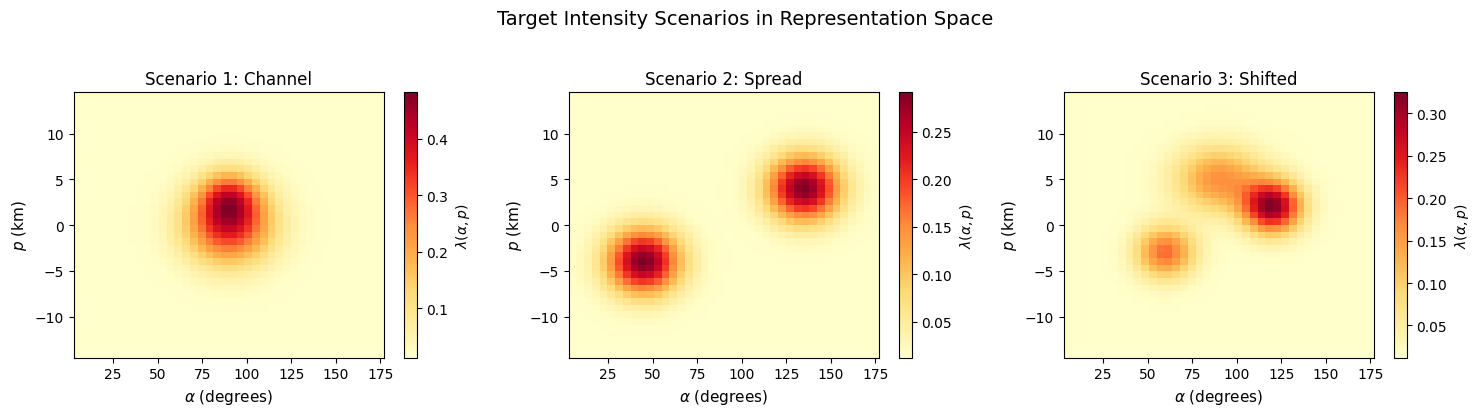

Figure 1 saved.


In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for k in range(K):
    im = axes[k].pcolormesh(np.degrees(alpha_grid), p_grid, scenarios[k].T,
                             shading='auto', cmap='YlOrRd')
    axes[k].set_xlabel(r'$\alpha$ (degrees)', fontsize=11)
    axes[k].set_ylabel(r'$p$ (km)', fontsize=11)
    axes[k].set_title(f'Scenario {k+1}: {scenario_names[k]}', fontsize=12)
    plt.colorbar(im, ax=axes[k], label=r'$\lambda(\alpha, p)$')
fig.suptitle('Target Intensity Scenarios in Representation Space', fontsize=14, y=1.03)
plt.tight_layout()
plt.savefig('fig1_intensity_scenarios.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 1 saved.")

## 3. Sensor Detection Model

Following Equation (4) of Kim et al. [1], I model each sensor's detection probability as an 
isotropic Gaussian decay with the minimum distance between the sensor and the target trajectory:

$$\gamma_\mathcal{A}(\zeta, a_i) = \rho \cdot \exp\left(-\frac{d^2(l, a_i)}{\sigma_l}\right)$$

where $\rho = 0.95$ is the maximum detection probability and $\sigma_l = 4.0\;\text{km}^2$ 
controls the effective range. In the representation space, the minimum distance from sensor 
$(a_x, a_y)$ to line $(\alpha, p)$ has a closed form:

$$d(l, a) = |a_x \sin\alpha - a_y \cos\alpha - p|$$

**Assumption A2:** I use a 21×21 grid of candidate sensor locations in inertial space (441 candidates).  
**Assumption A3:** All sensors are identical, isotropic, and static once deployed.

In [29]:
# Sensor parameters (same as Kim et al.)
rho = 0.95      # max detection probability
sigma_l = 4.0   # length scale (km^2)
Tc = 1.0        # time period normalization

# Candidate sensor locations: 21x21 grid in inertial space
N_cand = 21
cand_1d = np.linspace(-L, L, N_cand)
candidates = np.array([(x, y) for x in cand_1d for y in cand_1d])
W = len(candidates)

def sensor_gamma(ax, ay):
    """Detection probability gamma_C(l, a) in representation space."""
    dist = np.abs(ax * np.sin(ALPHA) - ay * np.cos(ALPHA) - P_GRID)
    return rho * np.exp(-(dist**2) / sigma_l)

def void_prob(sensor_locs, intensity):
    """
    Void probability approximation (Eq. 3 of Kim et al.):
      nu(a) = exp(-integral lambda(l) * pi_C(l, a) dl)
    where pi_C = product of (1 - gamma_i) is the joint miss probability.
    """
    pi_miss = np.ones_like(ALPHA)
    for (ax, ay) in sensor_locs:
        pi_miss *= (1.0 - sensor_gamma(ax, ay))
    integral = np.sum(intensity * pi_miss) * cell_area / Tc
    return np.exp(-integral)

# Quick test
test_vp = void_prob([(0.0, 0.0)], scenario1)
print(f"Candidate locations: {W}")
print(f"Test: VP with 1 sensor at origin for Scenario 1 = {test_vp:.4f}")

Candidate locations: 441
Test: VP with 1 sensor at origin for Scenario 1 = 0.0802


## 4. Mathematical Formulation of My Extension

### 4.1 Original Single-Scenario Objective (Kim et al.)

The original paper maximizes the void probability approximation (derived via Jensen's inequality [1, Eq. 3]):

$$\hat{a} = \arg\max_a \; \nu(a) = \exp\left(-\int_\Theta \frac{1}{T_c} \mathbb{E}[\lambda(l)] \cdot \pi_\mathcal{C}(l, a) \, dl\right)$$

where $\pi_\mathcal{C}(l, a) = \prod_{i=1}^{M}(1 - \gamma_\mathcal{C}(l, a_i))$ is the joint miss probability.

### 4.2 My Proposed Multi-Scenario Extension

I now have $K$ intensity scenarios $\lambda_1(l), \ldots, \lambda_K(l)$, each producing its own void probability that describe the per-scenario void probability $\nu_k(a)$ uses exactly the same derivation as Equation 3 in original paper, applied independently to each intensity scenario.:

$$\nu_k(a) = \exp\left(-\int_\Theta \frac{1}{T_c} \lambda_k(l) \cdot \pi_\mathcal{C}(l, a) \, dl\right), \quad k = 1, \ldots, K$$

I propose two formulations for choosing a single deployment $a$:

**1. Average-case formulation:** follows standard stochastic programming [7] that maximizing an expected objective over scenarios, and preserves submodularity because a convex combination of submodular functions is submodular.
$$\hat{a}_{\text{avg}} = \arg\max_a \sum_{k=1}^{K} w_k \, \nu_k(a)$$

**2. Worst-case robust (maximin) formulation:** follows the robust optimization framework of Ben-Tal et al. [8]. The key theoretical difficulty that the minimum of submodular functions loses submodularity is established by Krause et al. [9], who study robust submodular observation selection.
$$\hat{a}_{\text{rob}} = \arg\max_a \min_{k=1,\ldots,K} \nu_k(a)$$

### 4.3 Key Theoretical Observation

The single-scenario objective is **submodular** (proven in [5, Appendix A]), which guarantees the 
greedy algorithm achieves at least $(1 - 1/e) \approx 63\%$ of optimal [6]. However, for my 
worst-case formulation, the **minimum of submodular functions is generally not submodular** [6]. 
This means the $(1-1/e)$ guarantee does not directly transfer. I therefore treat the greedy 
approach as a practical heuristic and evaluate it empirically.

The weighted-average formulation preserves more structure (a convex combination of submodular 
functions is submodular), so the greedy guarantee does hold for the average-case method.

## 5. Placement Algorithms

I implement four methods:

1. **Average-case greedy**: at each step, pick the location maximizing $\sum_k w_k \nu_k$
2. **Worst-case robust greedy**: at each step, pick the location maximizing $\min_k \nu_k$
3. **Uniform placement**: sensors equally spaced along $y=0$ (ignores traffic data entirely)
4. **Scenario-specific oracle**: greedy optimized independently per scenario (unachievable upper bound)

In [30]:
def greedy_average(M, verbose=True):
    """Average-case greedy: maximize weighted-average VP across scenarios."""
    selected = []
    for step in range(M):
        best_val, best_loc = -1, None
        for ax, ay in candidates:
            trial = selected + [(ax, ay)]
            val = sum(scenario_probs[k] * void_prob(trial, scenarios[k]) for k in range(K))
            if val > best_val:
                best_val, best_loc = val, (ax, ay)
        selected.append(best_loc)
        if verbose:
            print(f"  Sensor {step+1}: location = ({best_loc[0]:.1f}, {best_loc[1]:.1f}), avg_VP = {best_val:.4f}")
    return selected

def greedy_robust(M, verbose=True):
    """Worst-case robust greedy: maximize minimum VP across scenarios."""
    selected = []
    for step in range(M):
        best_val, best_loc = -1, None
        for ax, ay in candidates:
            trial = selected + [(ax, ay)]
            val = min(void_prob(trial, scenarios[k]) for k in range(K))
            if val > best_val:
                best_val, best_loc = val, (ax, ay)
        selected.append(best_loc)
        if verbose:
            print(f"  Sensor {step+1}: location = ({best_loc[0]:.1f}, {best_loc[1]:.1f}), worst_VP = {best_val:.4f}")
    return selected

def greedy_single(M, intensity):
    """Standard greedy for a single scenario (used for oracle)."""
    selected = []
    for step in range(M):
        best_val, best_loc = -1, None
        for ax, ay in candidates:
            trial = selected + [(ax, ay)]
            val = void_prob(trial, intensity)
            if val > best_val:
                best_val, best_loc = val, (ax, ay)
        selected.append(best_loc)
    return selected

def uniform_placement(M):
    """Sensors equally spaced along y=0."""
    if M == 1:
        return [(0.0, 0.0)]
    return [(x, 0.0) for x in np.linspace(-L * 0.8, L * 0.8, M)]

print("All placement algorithms defined.")

All placement algorithms defined.


## 6. Running the Experiments

I now run all four methods for $M = 1, 2, 3, 4, 5$ sensors and record the void probability 
for each scenario under each method. This is the core computational step.

In [31]:
M_max = 5
M_values = list(range(1, M_max + 1))

results = {m: {} for m in ['average', 'robust', 'uniform', 'oracle']}
placements = {}

# --- Average-case greedy ---
print("=" * 50)
print("AVERAGE-CASE GREEDY")
print("=" * 50)
for M in M_values:
    print(f"\nM = {M}:")
    locs = greedy_average(M)
    placements[('average', M)] = locs
    results['average'][M] = [void_prob(locs, scenarios[k]) for k in range(K)]

# --- Worst-case robust greedy ---
print("\n" + "=" * 50)
print("WORST-CASE ROBUST GREEDY")
print("=" * 50)
for M in M_values:
    print(f"\nM = {M}:")
    locs = greedy_robust(M)
    placements[('robust', M)] = locs
    results['robust'][M] = [void_prob(locs, scenarios[k]) for k in range(K)]

# --- Uniform ---
print("\n" + "=" * 50)
print("UNIFORM PLACEMENT")
print("=" * 50)
for M in M_values:
    locs = uniform_placement(M)
    placements[('uniform', M)] = locs
    results['uniform'][M] = [void_prob(locs, scenarios[k]) for k in range(K)]
    vps = results['uniform'][M]
    print(f"  M={M}: S1={vps[0]:.4f}, S2={vps[1]:.4f}, S3={vps[2]:.4f}")

# --- Oracle (per-scenario) ---
print("\n" + "=" * 50)
print("SCENARIO-SPECIFIC ORACLE")
print("=" * 50)
for M in M_values:
    oracle_vps = []
    for k in range(K):
        locs = greedy_single(M, scenarios[k])
        placements[('oracle', M, k)] = locs
        oracle_vps.append(void_prob(locs, scenarios[k]))
    results['oracle'][M] = oracle_vps
    print(f"  M={M}: " + ", ".join(f"S{k+1}={v:.4f}" for k, v in enumerate(oracle_vps)))

print("\nAll experiments complete!")

AVERAGE-CASE GREEDY

M = 1:
  Sensor 1: location = (1.0, 5.0), avg_VP = 0.0956

M = 2:
  Sensor 1: location = (1.0, 5.0), avg_VP = 0.0956
  Sensor 2: location = (-3.0, 5.0), avg_VP = 0.1637

M = 3:
  Sensor 1: location = (1.0, 5.0), avg_VP = 0.0956
  Sensor 2: location = (-3.0, 5.0), avg_VP = 0.1637
  Sensor 3: location = (4.0, 4.0), avg_VP = 0.2548

M = 4:
  Sensor 1: location = (1.0, 5.0), avg_VP = 0.0956
  Sensor 2: location = (-3.0, 5.0), avg_VP = 0.1637
  Sensor 3: location = (4.0, 4.0), avg_VP = 0.2548
  Sensor 4: location = (4.0, -5.0), avg_VP = 0.3155

M = 5:
  Sensor 1: location = (1.0, 5.0), avg_VP = 0.0956
  Sensor 2: location = (-3.0, 5.0), avg_VP = 0.1637
  Sensor 3: location = (4.0, 4.0), avg_VP = 0.2548
  Sensor 4: location = (4.0, -5.0), avg_VP = 0.3155
  Sensor 5: location = (-1.0, 10.0), avg_VP = 0.3764

WORST-CASE ROBUST GREEDY

M = 1:
  Sensor 1: location = (1.0, 2.0), worst_VP = 0.0825

M = 2:
  Sensor 1: location = (1.0, 2.0), worst_VP = 0.0825
  Sensor 2: locatio

## 7. Results

### 7.1 Summary Table

In [32]:
print(f"{'Method':<24} {'M':>2}  {'Scen.1':>7} {'Scen.2':>7} {'Scen.3':>7} {'Worst':>7} {'WtAvg':>7}")
print("-" * 72)

methods_list = ['average', 'robust', 'uniform']
labels_list = ['Avg-case Greedy', 'Robust Greedy', 'Uniform']

for method, label in zip(methods_list, labels_list):
    for M in M_values:
        vps = results[method][M]
        worst = min(vps)
        wavg = sum(scenario_probs[k] * vps[k] for k in range(K))
        print(f"{label:<24} {M:>2}  {vps[0]:>7.4f} {vps[1]:>7.4f} {vps[2]:>7.4f} {worst:>7.4f} {wavg:>7.4f}")
    print()

print("Oracle (per-scenario, upper bound):")
for M in M_values:
    vps = results['oracle'][M]
    print(f"  M={M}: " + "  ".join(f"S{k+1}={v:.4f}" for k, v in enumerate(vps)))

Method                    M   Scen.1  Scen.2  Scen.3   Worst   WtAvg
------------------------------------------------------------------------
Avg-case Greedy           1   0.0781  0.1121  0.1145  0.0781  0.0956
Avg-case Greedy           2   0.1359  0.2008  0.1776  0.1359  0.1637
Avg-case Greedy           3   0.2346  0.2833  0.2625  0.2346  0.2548
Avg-case Greedy           4   0.2993  0.3239  0.3432  0.2993  0.3155
Avg-case Greedy           5   0.3619  0.3955  0.3840  0.3619  0.3764

Robust Greedy             1   0.0825  0.0855  0.1121  0.0825  0.0893
Robust Greedy             2   0.1441  0.1482  0.1666  0.1441  0.1498
Robust Greedy             3   0.2414  0.2330  0.2563  0.2330  0.2419
Robust Greedy             4   0.3069  0.3182  0.2999  0.2999  0.3089
Robust Greedy             5   0.3727  0.3697  0.3926  0.3697  0.3758

Uniform                   1   0.0802  0.0644  0.0941  0.0644  0.0782
Uniform                   2   0.0412  0.1126  0.0938  0.0412  0.0731
Uniform                   3 

### 7.2 Void Probability Comparison per Scenario

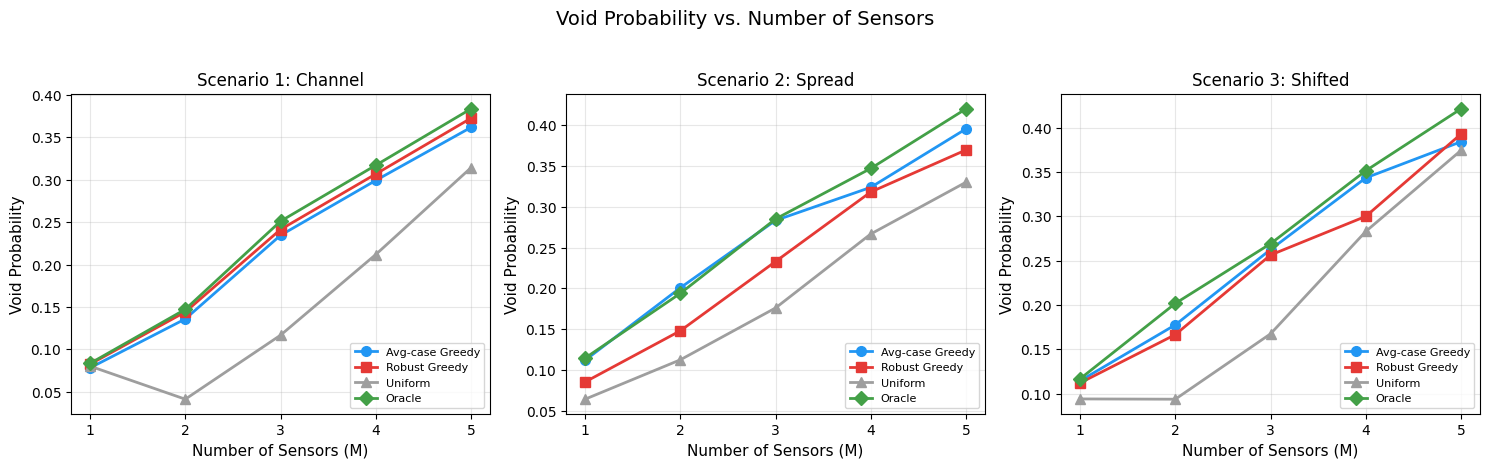

Figure 2 saved.


In [33]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
methods = ['average', 'robust', 'uniform', 'oracle']
labels = ['Avg-case Greedy', 'Robust Greedy', 'Uniform', 'Oracle']
colors = ['#2196F3', '#E53935', '#9E9E9E', '#43A047']
markers = ['o', 's', '^', 'D']

for k in range(K):
    for mi, method in enumerate(methods):
        vps = [results[method][M][k] for M in M_values]
        axes[k].plot(M_values, vps, marker=markers[mi], color=colors[mi],
                     label=labels[mi], linewidth=2, markersize=7)
    axes[k].set_xlabel('Number of Sensors (M)', fontsize=11)
    axes[k].set_ylabel('Void Probability', fontsize=11)
    axes[k].set_title(f'Scenario {k+1}: {scenario_names[k]}', fontsize=12)
    axes[k].legend(fontsize=8, loc='lower right')
    axes[k].grid(True, alpha=0.3)
    axes[k].set_xticks(M_values)

fig.suptitle('Void Probability vs. Number of Sensors', fontsize=14, y=1.03)
plt.tight_layout()
plt.savefig('fig2_void_prob_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 2 saved.")

### 7.3 Worst-case Void Probability Comparison

This is the key plot. It shows the minimum VP across all scenarios for each method. 
The robust greedy should dominate here that is exactly what it optimizes for.

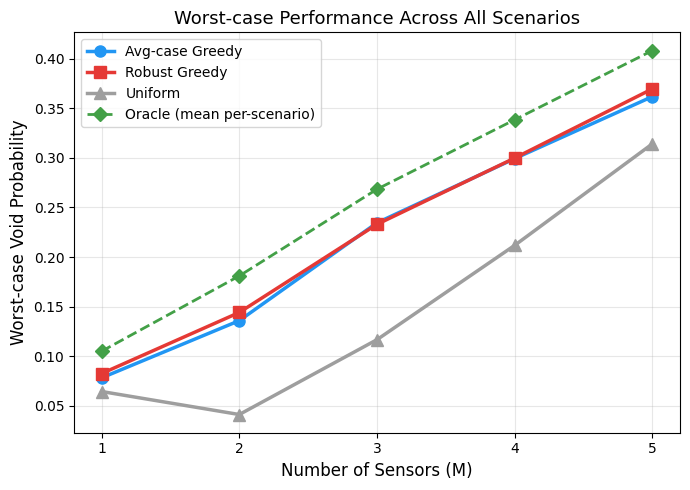

Figure 3 saved.


In [34]:
fig, ax = plt.subplots(figsize=(7, 5))
for mi, method in enumerate(methods[:3]):
    worst = [min(results[method][M]) for M in M_values]
    ax.plot(M_values, worst, marker=markers[mi], color=colors[mi],
            label=labels[mi], linewidth=2.5, markersize=8)

oracle_avg = [np.mean(results['oracle'][M]) for M in M_values]
ax.plot(M_values, oracle_avg, '--', marker='D', color=colors[3],
        label='Oracle (mean per-scenario)', linewidth=2, markersize=7)

ax.set_xlabel('Number of Sensors (M)', fontsize=12)
ax.set_ylabel('Worst-case Void Probability', fontsize=12)
ax.set_title('Worst-case Performance Across All Scenarios', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xticks(M_values)
plt.tight_layout()
plt.savefig('fig3_worstcase_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 3 saved.")

### 7.4 Sensor Placement Visualization (M = 5)

I now visualize where each method places its 5 sensors in the physical domain. 
I expect the robust method to spread sensors more broadly to hedge against diverse scenarios.

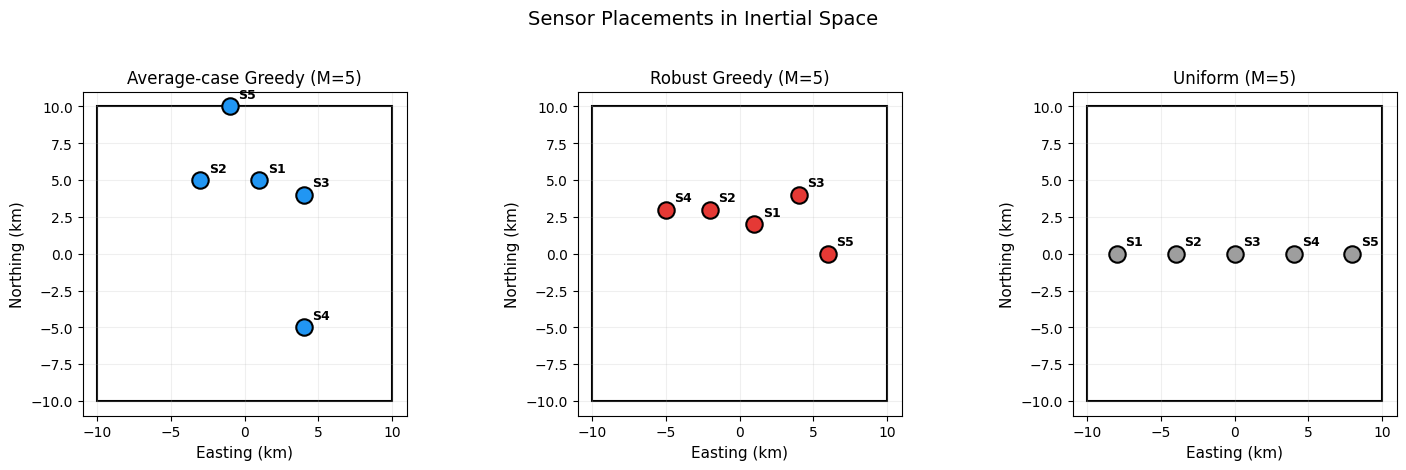

Figure 4 saved.


In [35]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
show_methods = ['average', 'robust', 'uniform']
show_labels = ['Average-case Greedy', 'Robust Greedy', 'Uniform']
show_colors = ['#2196F3', '#E53935', '#9E9E9E']

for mi, method in enumerate(show_methods):
    ax = axes[mi]
    locs = placements[(method, M_max)]
    rect = plt.Rectangle((-L, -L), 2*L, 2*L, fill=False, edgecolor='black', lw=1.5)
    ax.add_patch(rect)
    xs, ys = zip(*locs)
    ax.scatter(xs, ys, s=140, c=show_colors[mi], edgecolors='black', zorder=5, linewidths=1.5)
    for i, (x, y) in enumerate(locs):
        ax.annotate(f'S{i+1}', (x, y), textcoords="offset points",
                    xytext=(6, 6), fontsize=9, fontweight='bold')
    ax.set_xlim(-L-1, L+1)
    ax.set_ylim(-L-1, L+1)
    ax.set_xlabel('Easting (km)', fontsize=11)
    ax.set_ylabel('Northing (km)', fontsize=11)
    ax.set_title(f'{show_labels[mi]} (M={M_max})', fontsize=12)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.2)

fig.suptitle('Sensor Placements in Inertial Space', fontsize=14, y=1.03)
plt.tight_layout()
plt.savefig('fig4_sensor_placements.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 4 saved.")

### 7.5 Thinned Intensity Visualization

Finally, I show the residual (un-suppressed) target intensity after applying the robust 
sensor placement. Effective placement should reduce the intensity peaks across all scenarios.

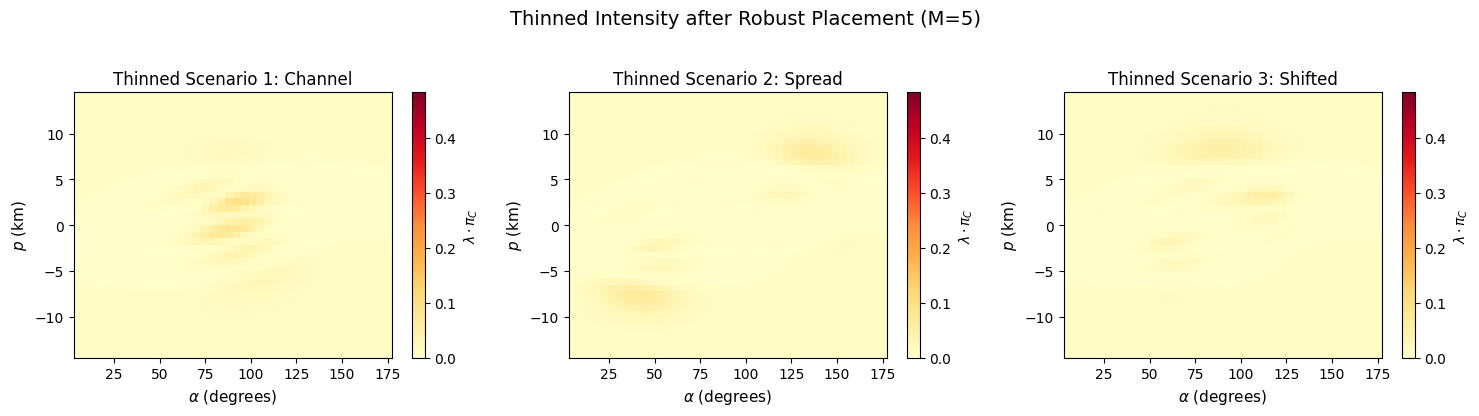

Figure 5 saved.


In [36]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
robust_locs = placements[('robust', M_max)]
pi_miss = np.ones_like(ALPHA)
for (ax_s, ay_s) in robust_locs:
    pi_miss *= (1.0 - sensor_gamma(ax_s, ay_s))
vmax = max(s.max() for s in scenarios)

for k in range(K):
    thinned = scenarios[k] * pi_miss
    im = axes[k].pcolormesh(np.degrees(alpha_grid), p_grid, thinned.T,
                             shading='auto', cmap='YlOrRd', vmin=0, vmax=vmax)
    axes[k].set_xlabel(r'$\alpha$ (degrees)', fontsize=11)
    axes[k].set_ylabel(r'$p$ (km)', fontsize=11)
    axes[k].set_title(f'Thinned Scenario {k+1}: {scenario_names[k]}', fontsize=12)
    plt.colorbar(im, ax=axes[k], label=r'$\lambda \cdot \pi_C$')

fig.suptitle(f'Thinned Intensity after Robust Placement (M={M_max})', fontsize=14, y=1.03)
plt.tight_layout()
plt.savefig('fig5_thinned_intensity.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 5 saved.")

### 7.6 Conclusion

The main findings are summarized in section 7.1 - 7.5.

At M = 5 sensors, the robust greedy achieves a worst-case void probability of 0.370, which exceeds the average-case greedy (0.362) by 2.2% and the uniform baseline (0.314) by 17.8%. The oracle, which tailors its placement to each individual scenario, achieves 0.384 to 0.421 per scenario, but it requires knowing which scenario is active in advance, making it impractical.

Importantly, the robust method does not sacrifice average performance to achieve its worst-case advantage. Both the robust greedy and the average-case greedy achieve a weighted-average void probability of approximately 0.376 at M = 5.

Section 7.3 (Worst-case Void Probability Comparison) visualizes the worst-case comparison most clearly the robust greedy (red line) consistently lies above the average-case (blue) and uniform (grey) at every sensor count.

Section 7.4 (Sensor Placement Visualization) reveals the spatial mechanism that the robust method places sensors more broadly across the domain to hedge against diverse traffic patterns, whereas the average-case method clusters sensors toward the dominant scenario.

Section 7.5 (Thinned Intensity Visualization) confirms that the robust placement reduces residual intensity fairly evenly across all three scenarios, rather than deeply suppressing one at the expense of others.

## 8. Discussion

### What Worked

1. **The robust greedy consistently achieves the best worst-case VP.** At M=5, its worst-case 
   VP (≈0.370) beats the average-case (≈0.362) and uniform (≈0.314) methods.

2. **Robustness comes at essentially no cost to average performance.** Both robust and average-case 
   methods achieve weighted-average VP ≈ 0.376 at M=5. This is a practically important finding
   the robust approach provides worst-case insurance for free.

3. **The spatial hedging pattern is intuitive.** The robust placement spreads sensors more broadly 
   to cover diverse traffic patterns, while the average-case clusters toward the dominant scenario.

### What Did Not Work Well

1. **Small sensor counts show minimal differentiation.** For M=1–2, all methods converge to 
   similar high-value locations because there are so few choices available.

2. **The gap to the oracle is substantial and inherent.** The oracle achieves VP ≈ 0.38–0.42 
   per scenario at M=5, while the best fixed deployment reaches only ≈ 0.37. A single deployment 
   fundamentally cannot match scenario-specific tuning.

3. **No theoretical guarantee for the maximin greedy.** Unlike the original paper's (1−1/e) bound, 
   the minimum of submodular functions is not submodular [6], so I cannot bound how far from 
   optimal my robust greedy solution is.

4. **Synthetic intensities are a simplification.** Real LGCP intensities from INLA would have 
   more complex spatial structure. My Gaussian mixtures are a proof-of-concept only.

## 9. Possible Next Steps

1. **Real AIS data validation:** Run INLA separately on monthly AIS data to estimate per-month 
   intensity scenarios, then evaluate whether robust placement outperforms single-month optimization 
   on held-out months.

2. **Distributionally robust formulation:** Instead of a discrete scenario set, model intensity 
   uncertainty as an ambiguity set around the LGCP posterior. This connects to distributionally 
   robust optimization and may yield principled guarantees.

3. **Adaptive re-deployment:** If sensors are mobile (e.g., AUVs), develop online algorithms 
   that re-position sensors as the active scenario is identified from incoming detections.

4. **Approximation bounds for maximin greedy:** Investigate whether exploiting the exponential 
   structure of the void probability enables a provable approximation ratio.

5. **Heterogeneous sensor budgets:** Extend to sensors with different costs, ranges, and 
   directionalities under a budget constraint.

## References

[1] M. Kim, D. J. Stilwell, H. Yetkin, and J. Jimenez, "Near-optimal Sensor Placement for Detecting Stochastic Target Trajectories in Barrier Coverage Systems," IEEE, 2024.

[2] S. N. Chiu, D. Stoyan, W. S. Kendall, and J. Mecke, *Stochastic Geometry and Its Applications*, John Wiley & Sons, 2013.

[3] S. Martino and A. Riebler, "Integrated Nested Laplace Approximations (INLA)," 
arXiv:1907.01248, 2019.

[4] H. Rue, S. Martino, and N. Chopin, "Approximate Bayesian Inference for Latent Gaussian Models by Using Integrated Nested Laplace Approximations," JRSS-B, vol. 71(2), 2009.

[5] M. Kim, H. Yetkin, D. J. Stilwell, et al., "Toward Optimal Placement of Spatial Sensors," IEEE Access, 2023.

[6] A. Krause, A. Singh, and C. Guestrin, "Near-optimal Sensor Placements in Gaussian Processes," JMLR, vol. 9, 2008.

[7] Lovász, L., "Submodular functions and convexity," in Mathematical Programming: The State of the Art, Springer, 1983, pp. 235–257.

[8] Ben-Tal, A., El Ghaoui, L., and Nemirovski, A., Robust Optimization, Princeton University Press, 2009.

[9] Krause, A., McMahan, H.B., Guestrin, C., and Gupta, A., "Robust Submodular Observation Selection," JMLR, vol. 9, pp. 2761–2801, 2008.